# Importations

In [1]:
# Numerical and scientific python programming
import numpy as np

import matplotlib.pyplot as plt

# Local importations
from moments.bloch import compute_bipartite_region_upper, compute_bipartite_region_lower

# Loading and Saving
from moments.saving import get_experiment_paths

data_dir, plots_dir = get_experiment_paths(__vsc_ipynb_file__)

# Symmetric plane

## Importations and definitions

In [2]:
bloch_distance = np.load(data_dir / "sym_bloch_distance.npy")
Dt, Dz = bloch_distance.shape

t = np.linspace(0, 2, Dt)
x = t / np.sqrt(2)
z = np.linspace(0, 2*np.sqrt(2), Dz)

X, Z = np.meshgrid(x, z, indexing='ij')

In [3]:
indices = np.ndindex(X.shape)
success = np.full_like(X, np.False_)
for idx, jdx in indices:
    if bloch_distance[idx, jdx] <= 1e-3:
        success[idx, jdx] = np.True_

## Plots

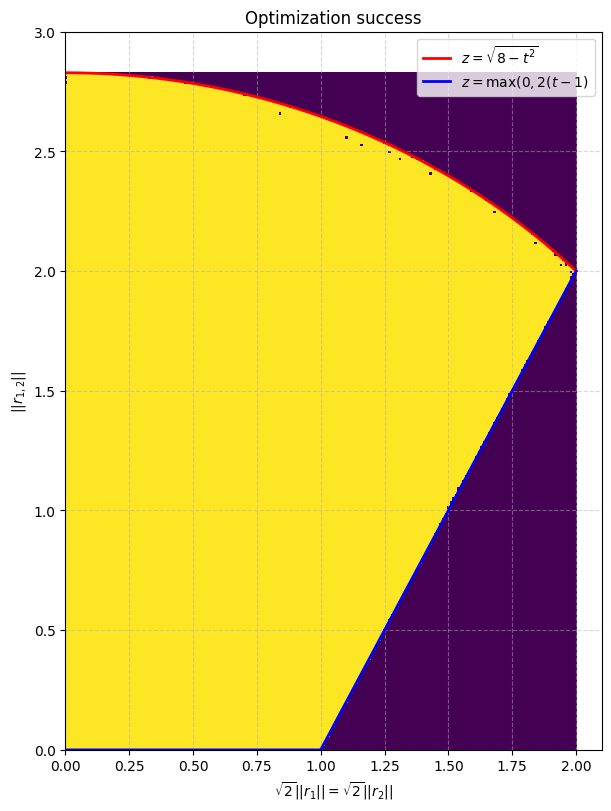

In [4]:
fig, ax = plt.subplots(figsize=(6, 8), constrained_layout=True)

mesh = ax.pcolormesh(np.sqrt(2) * X, Z, success, shading='auto', vmin=0, vmax=1)

ax.set(xlabel=r"$\sqrt{2} || r_1 || = \sqrt{2} || r_2 ||$", ylabel=r"$||r_{1, 2}||$",
       xlim=(0, 2.1), ylim=(0, 3), title="Optimization success")

t = np.linspace(0, 2, 1000)
x = t / np.sqrt(2)
z_upper = compute_bipartite_region_upper(3, x, x)
z_lower = compute_bipartite_region_lower([3, 3], x, x)

ax.plot(t, z_upper, 'red', linewidth=2, label=r"$z = \sqrt{8 - t^2}$")
ax.plot(t, z_lower, 'blue', linewidth=2, label=r"$z = \max(0, 2 (t - 1)$")

ax.legend(loc='upper right')
ax.grid(True, alpha=0.5, linestyle="--")
ax.legend()
plt.show()

# $xz$-plane

## Importations and definitions

In [5]:
bloch_distance = np.load(data_dir / "xz_bloch_distance.npy")
Dx, Dz = bloch_distance.shape

x = np.linspace(0, np.sqrt(2), Dx)
z = np.linspace(0, 2*np.sqrt(2), Dz)

X, Z = np.meshgrid(x, z, indexing='ij')

In [6]:
indices = np.ndindex(X.shape)
success = np.full_like(X, np.False_)
for idx, jdx in indices:
    if bloch_distance[idx, jdx] <= 1e-3:
        success[idx, jdx] = np.True_

## Plots

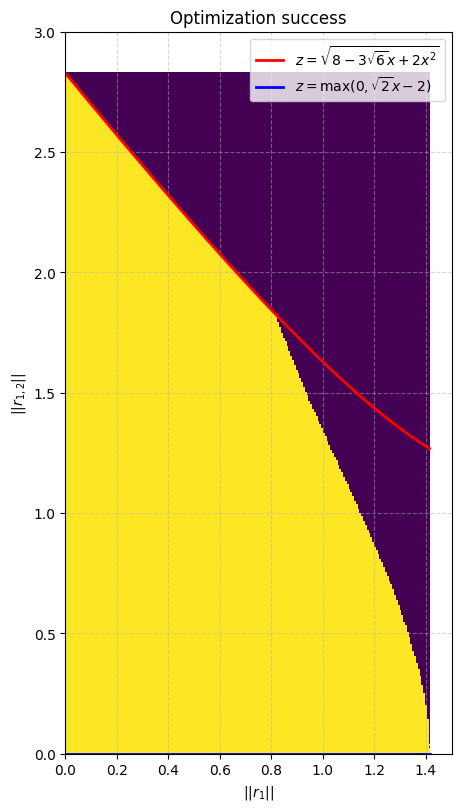

In [7]:
fig, ax = plt.subplots(figsize=(4.5, 8), constrained_layout=True)

mesh = ax.pcolormesh(X, Z, success, shading='auto', vmin=0, vmax=1)

ax.set(xlabel=r"$|| r_1 ||$", ylabel=r"$||r_{1, 2}||$",
       xlim=(0, 1.5), ylim=(0, 3), title="Optimization success")

x = np.linspace(0, np.sqrt(2), 1000)
z_upper = compute_bipartite_region_upper(3, x, 0)
z_lower = compute_bipartite_region_lower([3, 3], x, 0)

ax.plot(x, z_upper, 'red', linewidth=2, label=r"$z = \sqrt{8 - 3\sqrt{6}x + 2x^2}$")
ax.plot(x, z_lower, 'blue', linewidth=2, label=r"$z = \max(0, \sqrt{2} x - 2)$")

ax.legend(loc='upper right')
ax.grid(True, alpha=0.5, linestyle="--")
ax.legend()
plt.show()